In [491]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [492]:
X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)
x1 = X[y==0,0]
y1 = X[y==0,1]
x2 = X[y==1,0]
y2 = X[y==1,1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.Tensor(y_train)
y_test = torch.Tensor(y_test)
print(X.shape)
print(y.shape)
print(y_train.shape)

(1000, 2)
(1000,)
torch.Size([800])


In [493]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [494]:
class MoonsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,20)
        self.fc2 = nn.Linear(20, 20)
        self.fc3 = nn.Linear(20,40)
        self.fc4 = nn.Linear(40,1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x= self.fc2(x)
        x = self.relu(x)
        x= self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [495]:
def train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer):
    model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device).reshape(-1,1)
    X_test = X_test.to(device)
    y_test = y_test.to(device).reshape(-1,1)
    y_pred = torch.Tensor().to(device)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        if (epoch%20==0):
            model.eval()
            with torch.no_grad():
            #     acc = torch.Tensor(model(x_train) - y_train).abs().sum() / len(x_train)
                # acc = 1-torch.Tensor(nn.Sigmoid()(model(x_test)-y_test).abs().sum().item()/len(x_test)
                acc = torch.Tensor(y_test == (nn.Sigmoid()(model(X_test))>=.5)).sum().to(device)/len(X_test)
                print(f"epoch {epoch}:\tloss: {loss:.6f}\tacc: {acc:.2f}")


In [496]:
model = MoonsClassifier()
criterion = nn.BCEWithLogitsLoss()
optim = optim.Adam(model.parameters())
epochs = 1000

In [497]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optim)

epoch 0:	loss: 0.693352	acc: 0.51
epoch 20:	loss: 0.659114	acc: 0.51
epoch 40:	loss: 0.592084	acc: 0.84
epoch 60:	loss: 0.485329	acc: 0.89
epoch 80:	loss: 0.385020	acc: 0.89
epoch 100:	loss: 0.316848	acc: 0.91
epoch 120:	loss: 0.277938	acc: 0.92
epoch 140:	loss: 0.248179	acc: 0.94
epoch 160:	loss: 0.219699	acc: 0.95
epoch 180:	loss: 0.190474	acc: 0.96
epoch 200:	loss: 0.160996	acc: 0.97
epoch 220:	loss: 0.133787	acc: 0.99
epoch 240:	loss: 0.112298	acc: 0.99
epoch 260:	loss: 0.097361	acc: 0.99
epoch 280:	loss: 0.087362	acc: 0.99
epoch 300:	loss: 0.080474	acc: 0.99
epoch 320:	loss: 0.076194	acc: 0.99
epoch 340:	loss: 0.073309	acc: 0.99
epoch 360:	loss: 0.071148	acc: 0.99
epoch 380:	loss: 0.069660	acc: 0.99
epoch 400:	loss: 0.068574	acc: 0.99
epoch 420:	loss: 0.067753	acc: 0.99
epoch 440:	loss: 0.067050	acc: 0.99
epoch 460:	loss: 0.066402	acc: 0.99
epoch 480:	loss: 0.065895	acc: 0.99
epoch 500:	loss: 0.065509	acc: 0.99
epoch 520:	loss: 0.065121	acc: 0.99
epoch 540:	loss: 0.064827	acc: 0.9

(1000,) (1000, 2)


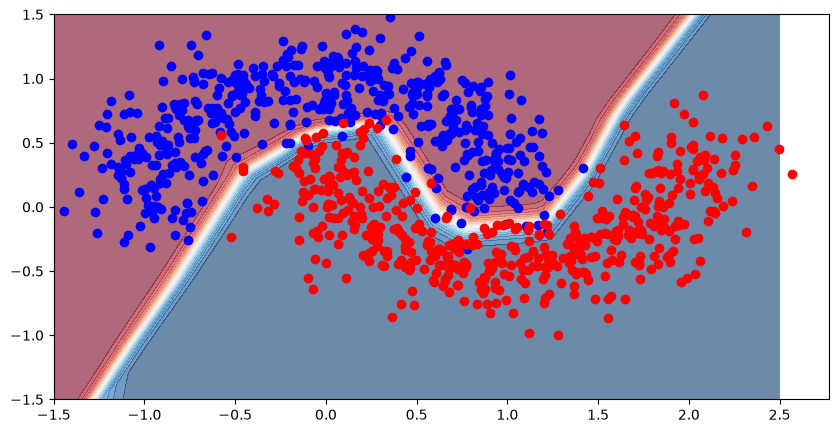

In [498]:

xx, yy = np.meshgrid(
    np.linspace(-1.5, 2.5, 500),
    np.linspace(-1.5, 1.5, 500)
)

grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

y_pred = nn.Sigmoid()(model(torch.Tensor(grid).to(device))).detach().cpu().numpy().reshape(xx.shape)
plt.figure(figsize=(10,5))
# plt.plot(y_pred)
plt.contourf(xx, yy, y_pred, levels=20, cmap="RdBu", alpha=0.6)
print(y.shape, X.shape)
plt.scatter(x1, y1, c="blue")
plt.scatter(x2, y2, c="red")
plt.show()